# Préparation — Shifaa (arabe)

**Pipeline complet :**
1. Chargement brut
2. Suppression des valeurs manquantes
3. Dédoublonnage sur (Question, Answer, Hierarchical Diagnosis) conjointement — pas colonne par colonne
4. Vérification qualité : caractères de remplacement, séquences `???`, HTML/liens résiduels
5. Normalisation arabe légère
6. Filtre de langue : ratio de caractères arabes (tolérance aux termes techniques latins)
7. Statistiques de longueur
8. Filtre de longueur hybride : plancher fixe métier + plafond P99 statistique
9. Construction du document RAG au format Markdown
10. Export CSV + métadonnées + configuration justificative

In [ ]:
!pip install -q datasets

import pandas as pd
import numpy as np
import re
import json
import os
import unicodedata
import matplotlib.pyplot as plt
from datasets import load_dataset
from google.colab import drive

drive.mount('/content/drive')

BASE_DRIVE = '/content/drive/MyDrive/Master_Thesis_RAG_Indexes'
OUTPUT_DIR = f"{BASE_DRIVE}/Shifaa"
os.makedirs(OUTPUT_DIR, exist_ok=True)

step_counts = {}

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Master_Thesis_RAG_Indexes/Shifaa/shifaa_prepared_rag.csv")
distribution = df['disorder'].value_counts(normalize=True) * 100
print(distribution.round(1))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
disorder
الحالات النفسية العصبية      69.6
الشخصية وتطوير الذات         12.7
الحالات النفسية السلوكية      7.7
الأمراض الذهانية              4.9
قضايا وإرشادات نفسية عامة     2.4
مشاكل الطفل النفسية           2.0
قضايا نفسية وسلوكية أخرى      0.7
Name: proportion, dtype: float64


## 1. Chargement brut

In [ ]:
ds = load_dataset("Ahmed-Selem/Shifaa_Arabic_Mental_Health_Consultations")
df = ds['train'].to_pandas()
step_counts['1_brut'] = len(df)
print(f"1. Brut : {step_counts['1_brut']} lignes")

README.md:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

Behavioral_Psychological_Conditions.csv: reconstructing file:   0%|          |  0.00B / 13.7MB            

Behavioral_Psychological_Conditions.csv: downloading bytes:           |  0.00B            

Childhood_Psychological_Problems.csv:   0%|          | 0.00/3.47M [00:00<?, ?B/s]

Neuropsychological_Conditions.csv: reconstructing file:   0%|          |  0.00B /  146MB            

...

Personality_and_Self_Development.csv: downloading bytes:           |  0.00B            

Psychological_Issues_and_Guidance.csv:   0%|          | 0.00/4.92M [00:00<?, ?B/s]

Psychotic_Disorders.csv:   0%|          | 0.00/9.39M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/35648 [00:00<?, ? examples/s]

1. Brut : 35648 lignes


## 2. Suppression des valeurs manquantes

In [ ]:
df.dropna(subset=['Question', 'Answer', 'Hierarchical Diagnosis'], inplace=True)
step_counts['2_dropna'] = len(df)
print(f"2. Après suppression valeurs manquantes : {step_counts['2_dropna']} lignes "
      f"(-{step_counts['1_brut'] - step_counts['2_dropna']})")

2. Après suppression valeurs manquantes : 35648 lignes (-0)


## 3. Dédoublonnage conjoint (Question + Answer + Diagnostic)

**Correction** : dédupliquer Question puis Answer séparément risque de supprimer des paires légitimes
(même question posée par deux patients avec des réponses différentes, ou inversement). Le doublon n'est
réel que si les trois champs coïncident.

In [ ]:
df.drop_duplicates(subset=['Question', 'Answer', 'Hierarchical Diagnosis'], inplace=True)
step_counts['3_dedup'] = len(df)
print(f"3. Après dédoublonnage conjoint : {step_counts['3_dedup']} lignes "
      f"(-{step_counts['2_dropna'] - step_counts['3_dedup']})")

3. Après dédoublonnage conjoint : 35648 lignes (-0)


## 4. Vérification qualité : caractères invalides, placeholders, HTML/liens

Détecte (avant nettoyage) la présence de caractères de remplacement Unicode (`�`), de séquences `???`
typiques d'un problème d'encodage, et de résidus HTML/liens — pour quantifier l'ampleur du problème
avant de décider s'il faut nettoyer ou exclure ces lignes.

In [ ]:
def detect_quality_issues(text):
    if not isinstance(text, str):
        return {'replacement_char': False, 'question_marks_placeholder': False, 'html_or_link': False}
    return {
        'replacement_char': '\ufffd' in text,
        'question_marks_placeholder': bool(re.search(r'\?{3,}', text)),
        'html_or_link': bool(re.search(r'<[^>]+>|https?://\S+|www\.\S+', text))
    }

issues_q = df['Question'].apply(detect_quality_issues)
issues_a = df['Answer'].apply(detect_quality_issues)

for key in ['replacement_char', 'question_marks_placeholder', 'html_or_link']:
    n_q = sum(i[key] for i in issues_q)
    n_a = sum(i[key] for i in issues_a)
    print(f"{key:30s} : {n_q} questions, {n_a} réponses concernées")

replacement_char               : 0 questions, 0 réponses concernées
question_marks_placeholder     : 1 questions, 0 réponses concernées
html_or_link                   : 7 questions, 29 réponses concernées


## 5. Normalisation arabe + nettoyage HTML/liens/placeholders

In [ ]:
def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.replace('\ufffd', '')
    text = re.sub(r'\?{3,}', '', text)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    text = re.sub(r'\u0640', '', text)
    text = re.sub(r'[\u0622\u0623\u0625]', '\u0627', text)
    text = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', text)
    text = re.sub(r'[\u200B-\u200F\u202A-\u202E\uFEFF]', '', text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Question_Clean'] = df['Question'].apply(clean_arabic_text)
df['Answer_Clean'] = df['Answer'].apply(clean_arabic_text)
print("✅ Normalisation arabe + nettoyage HTML/liens/placeholders appliqués")

✅ Normalisation arabe + nettoyage HTML/liens/placeholders appliqués


## 6. Filtre de langue — ratio de caractères arabes

**Tolérance volontaire** : seuil à 0.5 (pas plus strict), car des réponses cliniquement valides
contiennent parfois des termes techniques en latin (noms de médicaments, sigles DSM/ICD) mélangés
à l'arabe. Un seuil trop strict exclurait ces réponses légitimes.

In [ ]:
ARABIC_RANGE = re.compile(r'[\u0600-\u06FF]')

def arabic_ratio(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    arabic_chars = len(ARABIC_RANGE.findall(text))
    non_space_len = len(text.replace(' ', ''))
    return arabic_chars / non_space_len if non_space_len > 0 else 0.0

df['answer_arabic_ratio'] = df['Answer_Clean'].apply(arabic_ratio)

ARABIC_RATIO_THRESHOLD = 0.5
n_before_lang_filter = len(df)
df = df[df['answer_arabic_ratio'] >= ARABIC_RATIO_THRESHOLD]
step_counts['4_filtre_langue'] = len(df)
print(f"4. Après filtre de langue (ratio arabe >= {ARABIC_RATIO_THRESHOLD}) : {step_counts['4_filtre_langue']} lignes "
      f"(-{n_before_lang_filter - step_counts['4_filtre_langue']})")

4. Après filtre de langue (ratio arabe >= 0.5) : 35648 lignes (-0)


## 7. Statistiques de longueur — avant filtrage final

In [ ]:
df['question_length'] = df['Question_Clean'].str.len()
df['answer_length'] = df['Answer_Clean'].str.len()

length_stats = {}
for col, label in [('question_length', 'Questions'), ('answer_length', 'Réponses')]:
    lengths = df[col]
    stats = {
        'min': int(lengths.min()), 'max': int(lengths.max()),
        'mean': float(lengths.mean()), 'median': float(lengths.median()),
        'p1': float(np.percentile(lengths, 1)), 'p90': float(np.percentile(lengths, 90)),
        'p99': float(np.percentile(lengths, 99))
    }
    length_stats[label] = stats
    print(f"\n{label} :")
    for k, v in stats.items():
        print(f"  {k:8s} : {v:.0f}" if isinstance(v, float) else f"  {k:8s} : {v}")


Questions :
  min      : 26
  max      : 20305
  mean     : 893
  median   : 753
  p1       : 104
  p90      : 1645
  p99      : 2931

Réponses :
  min      : 227
  max      : 14730
  mean     : 2097
  median   : 1953
  p1       : 645
  p90      : 3203
  p99      : 5344


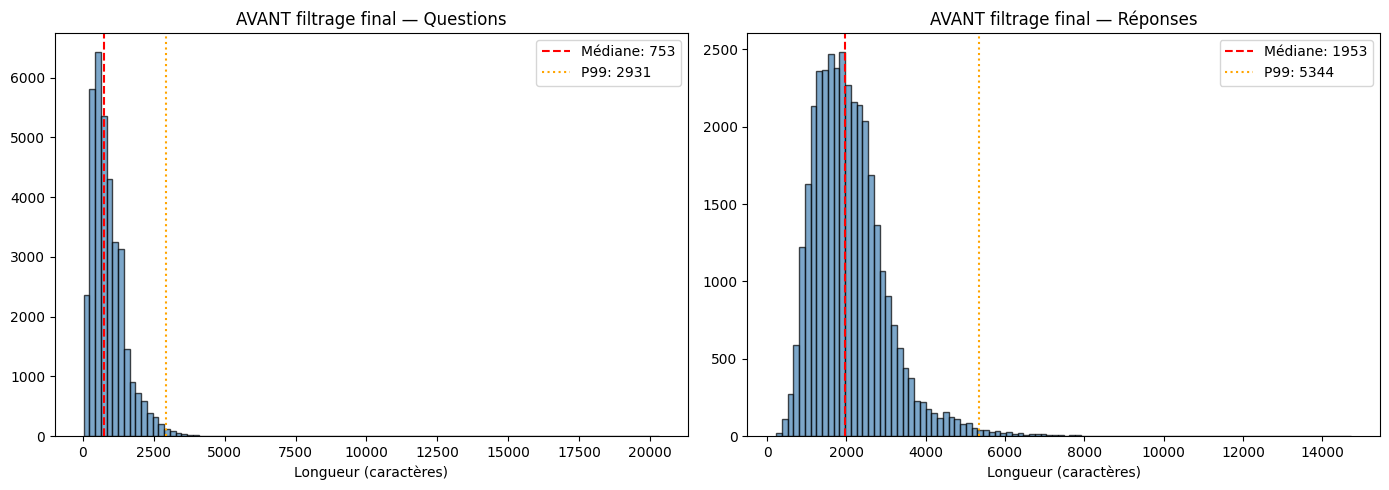

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['question_length', 'answer_length'], ['Questions', 'Réponses']):
    lengths = df[col]
    ax.hist(lengths, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'Médiane: {lengths.median():.0f}')
    ax.axvline(np.percentile(lengths, 99), color='orange', linestyle=':', label=f'P99: {np.percentile(lengths, 99):.0f}')
    ax.set_title(f'AVANT filtrage final — {label}')
    ax.set_xlabel('Longueur (caractères)')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_distribution_before.png', dpi=150)
plt.show()

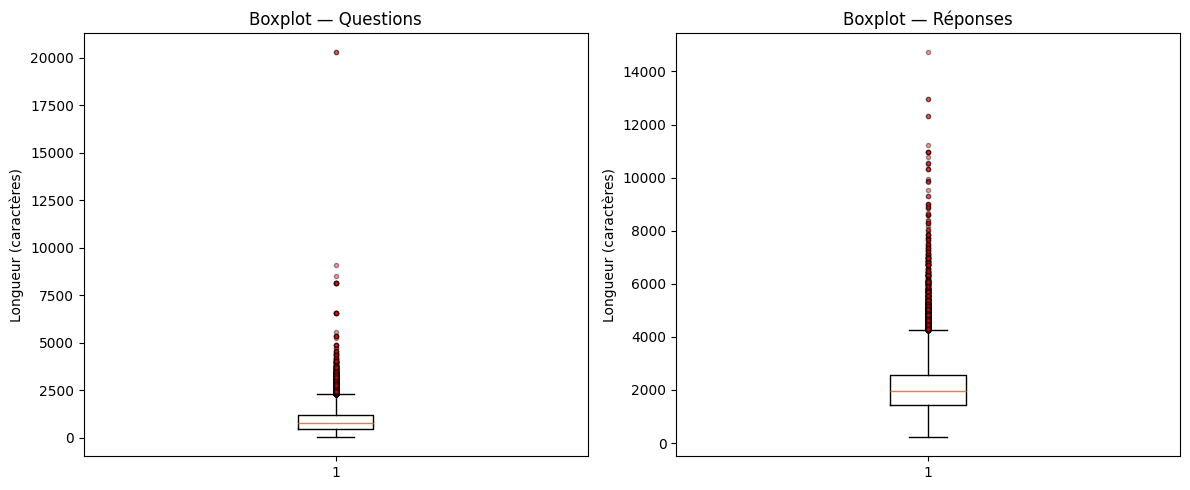

In [ ]:

# GRAPHIQUE 1 : Boxplot — repérer visuellement les valeurs aberrantes

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, label in zip(axes, ['question_length', 'answer_length'], ['Questions', 'Réponses']):
    ax.boxplot(df[col], vert=True, showfliers=True,
               flierprops={'markerfacecolor': 'red', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(f'Boxplot — {label}')
    ax.set_ylabel('Longueur (caractères)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_boxplot.png', dpi=150)
plt.show()

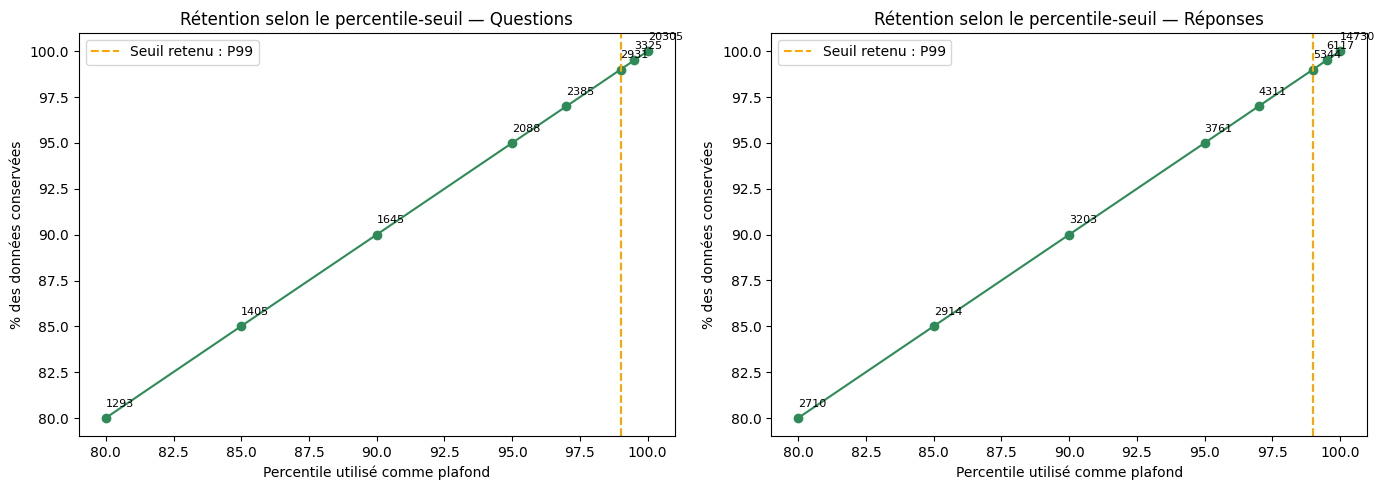

In [ ]:

# GRAPHIQUE : Sensibilité du taux de rétention selon le seuil maximal choisi
# Répond à la question "pourquoi P99 et pas P95 ou P90 ?" en montrant
# concrètement combien de données chaque choix de seuil ferait perdre.

candidate_percentiles = [80, 85, 90, 95, 97, 99, 99.5, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['question_length', 'answer_length'], ['Questions', 'Réponses']):
    thresholds = [np.percentile(df[col], p) for p in candidate_percentiles]
    retention = [(df[col] <= t).sum() / len(df) * 100 for t in thresholds]

    ax.plot(candidate_percentiles, retention, marker='o', color='seagreen')
    ax.axvline(99, color='orange', linestyle='--', label='Seuil retenu : P99')
    for p, t, r in zip(candidate_percentiles, thresholds, retention):
        ax.annotate(f'{t:.0f}', (p, r), textcoords="offset points", xytext=(0, 8), fontsize=8)

    ax.set_title(f'Rétention selon le percentile-seuil — {label}')
    ax.set_xlabel('Percentile utilisé comme plafond')
    ax.set_ylabel('% des données conservées')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_threshold_sensitivity.png', dpi=150)
plt.show()

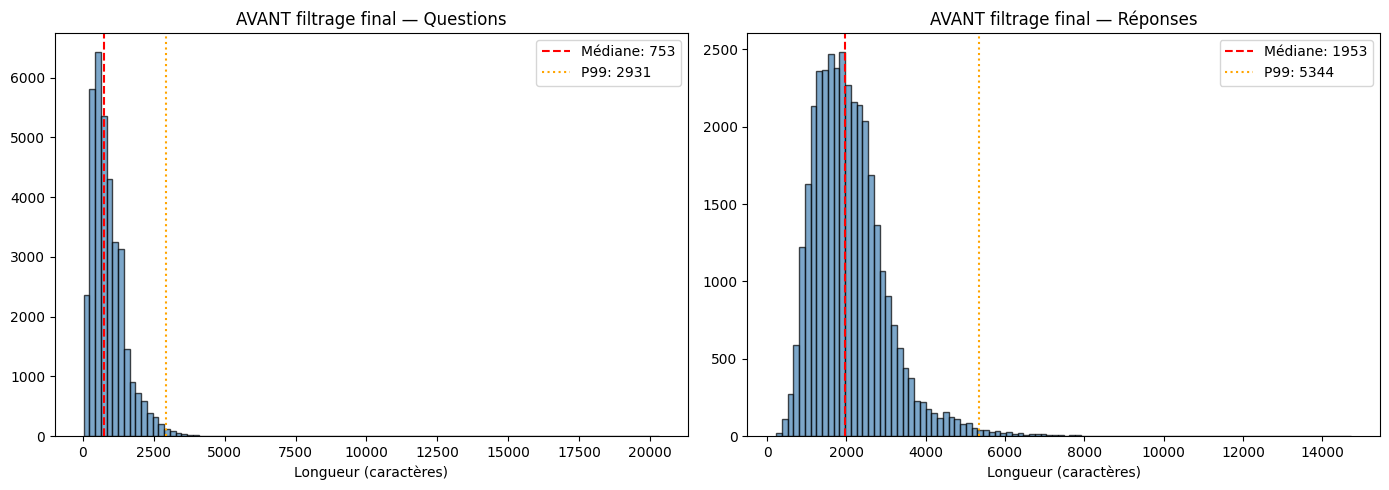

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['question_length', 'answer_length'], ['Questions', 'Réponses']):
    lengths = df[col]
    ax.hist(lengths, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'Médiane: {lengths.median():.0f}')
    ax.axvline(np.percentile(lengths, 99), color='orange', linestyle=':', label=f'P99: {np.percentile(lengths, 99):.0f}')
    ax.set_title(f'AVANT filtrage final — {label}')
    ax.set_xlabel('Longueur (caractères)')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_distribution_before.png', dpi=150)
plt.show()

## 8. Filtre de longueur hybride : plancher métier fixe + plafond statistique P99

**Justification** : un plancher basé sur le percentile 1% (P1) exclut des réponses courtes mais
parfaitement valides cliniquement (ex: une consigne de traitement brève). On utilise donc un plancher
fixe, choisi selon une longueur minimale jugée informative pour chaque type de champ (Question : 50
caractères, Answer : 150 caractères), combiné à un plafond P99 qui, lui, reste statistique car les
anomalies de longueur excessive (doublons internes, erreurs de scraping) sont bien identifiées par ce
seuil.

In [ ]:
MIN_LEN_QUESTION = 50
MIN_LEN_ANSWER = 150
max_len_q = np.percentile(df['question_length'], 99)
max_len_a = np.percentile(df['answer_length'], 99)

print(f"Seuils appliqués :")
print(f"  Question : {MIN_LEN_QUESTION} - {max_len_q:.0f} caractères")
print(f"  Answer   : {MIN_LEN_ANSWER} - {max_len_a:.0f} caractères")

n_before_length_filter = len(df)
df = df[
    df['question_length'].between(MIN_LEN_QUESTION, max_len_q) &
    df['answer_length'].between(MIN_LEN_ANSWER, max_len_a)
]
step_counts['5_filtre_longueur'] = len(df)
print(f"\n5. Après filtre de longueur hybride : {step_counts['5_filtre_longueur']} lignes "
      f"(-{n_before_length_filter - step_counts['5_filtre_longueur']})")

Seuils appliqués :
  Question : 50 - 2931 caractères
  Answer   : 150 - 5344 caractères

5. Après filtre de longueur hybride : 34912 lignes (-736)


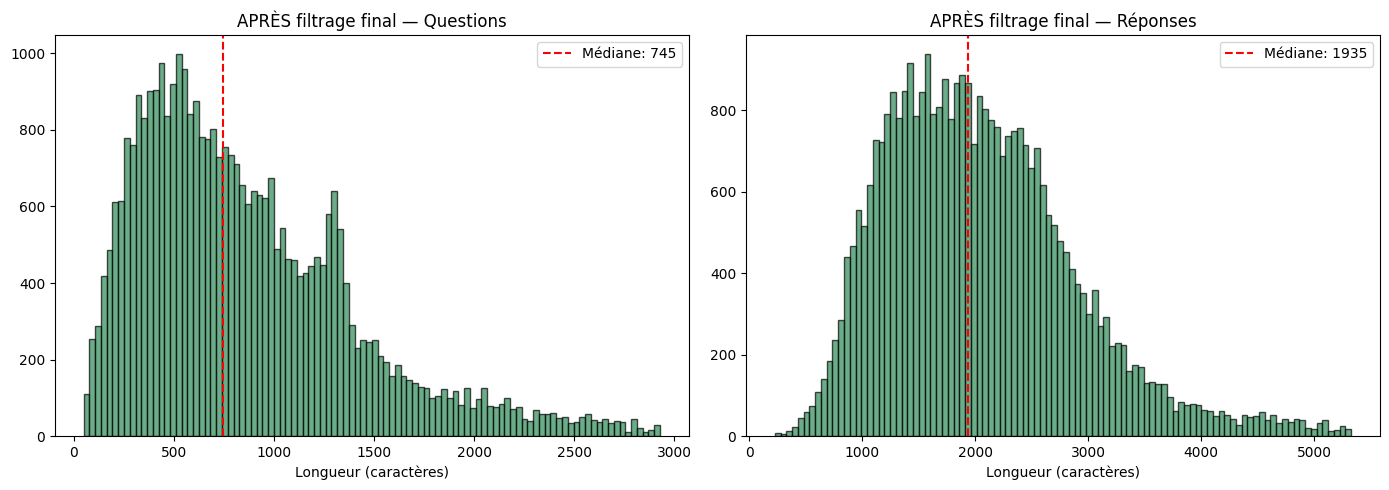

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['question_length', 'answer_length'], ['Questions', 'Réponses']):
    lengths = df[col]
    ax.hist(lengths, bins=100, edgecolor='black', alpha=0.7, color='seagreen')
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'Médiane: {lengths.median():.0f}')
    ax.set_title(f'APRÈS filtrage final — {label}')
    ax.set_xlabel('Longueur (caractères)')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_distribution_after.png', dpi=150)
plt.show()

## 9. Récapitulatif visuel du pipeline complet 

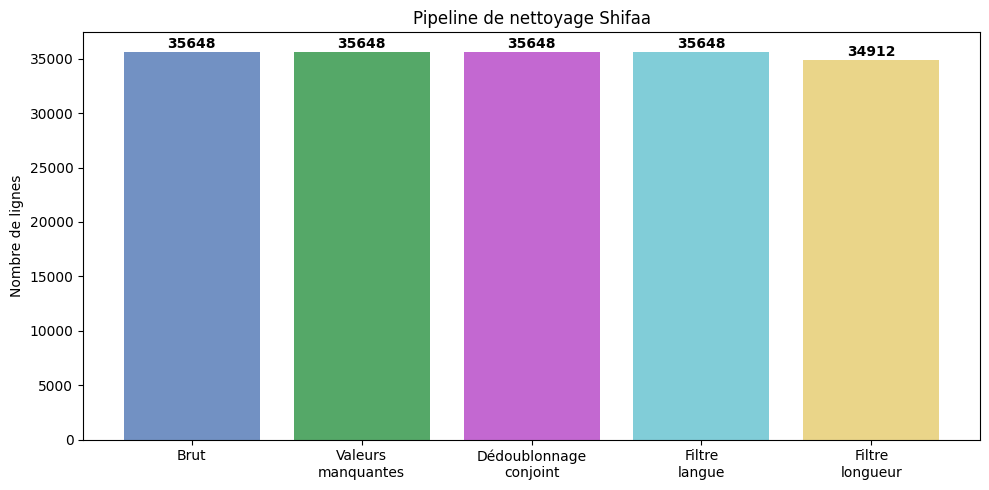


📊 Taux de rétention global : 97.9%


In [ ]:
steps_labels = ['Brut', 'Valeurs\nmanquantes', 'Dédoublonnage\nconjoint', 'Filtre\nlangue', 'Filtre\nlongueur']
steps_values = [
    step_counts['1_brut'], step_counts['2_dropna'], step_counts['3_dedup'],
    step_counts['4_filtre_langue'], step_counts['5_filtre_longueur']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(steps_labels, steps_values, color=["#7291C3", '#55A868', "#C368D1", "#81CDD8", "#EAD589"])
for bar, val in zip(bars, steps_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 300, f'{val}', ha='center', fontweight='bold')
ax.set_ylabel('Nombre de lignes')
ax.set_title('Pipeline de nettoyage Shifaa')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cleaning_funnel.png', dpi=150)
plt.show()

taux_retention = steps_values[-1] / steps_values[0] * 100
print(f"\n📊 Taux de rétention global : {taux_retention:.1f}%")

## 10. Construction du document RAG — format Markdown

Format harmonisé avec les guidelines (déjà structurées en Markdown avec titres `##`), pour une
cohérence visuelle dans la base de connaissances finale.

In [ ]:
df['Main_Category'] = df['Hierarchical Diagnosis'].apply(
    lambda x: x.split(' - ')[0] if ' - ' in str(x) else str(x)
)

df['RAG_Document'] = df.apply(lambda row: f"""**Language:** Arabic

## Diagnosis
{row['Hierarchical Diagnosis']}

## Patient
{row['Question_Clean']}

## Doctor
{row['Answer_Clean']}""".strip(), axis=1)

print("✅ Documents RAG construits (format Markdown)")
print(df['RAG_Document'].iloc[0])

✅ Documents RAG construits (format Markdown)
**Language:** Arabic

## Diagnosis
الحالات النفسية السلوكية - مشاكل النوم - أحلام اليقظة

## Patient
السلام عليكم ورحمة الله وبركاتهاعاني منذ سنوات من تخيل بعض المواقف في ذهني، حول خلافي او شجاري مع شخص ما، واشعر بانفعال شديد بسبب هذه الخيالات، لدرجة تصل الى ارتفاع معدل ضربات القلب بشكل ملحوظ، وارتفاع الضغط، فذهبت الى طبيب القلب، ووصف لي دواء الاندرال، ولكني ما زلت اعاني من الخيالات، فما سببها؟ وهل لها علاج؟

## Doctor
بسم الله الرحمن الرحيمالاخ الفاضل/ محمد حفظه الله.السلام عليكم ورحمة الله وبركاته، وبعد:نرحب بك في اسلام ويب، واسال الله لك العافية والشفاء.ظهور خيالات او افكار واقعية او غير واقعية، وتكون كثيرة ومكثفة، وتؤدي الى مضايقات وتغيرات مزاجية، وحتى تغيرات فسيولوجية، مثل: ظاهرة تسارع ضربات القلب التي تحدث لك، هذا -يا اخي- يدل على وجود قلق نفسي داخلي، وكذلك وجود احتقانات نفسية.كثيرا ما تتحول مشاعر عدم الرضا الى نوع من الطاقات النفسية التي تظهر في شكل خيالات، او الظواهر من النوع الذي تحدثت عنه؛ فانا اقول لك: حاول ان تعبر عن نفسك، لا تسك

## 11. Sauvegarde — CSV, métadonnées, configuration justificative complète

In [ ]:
records = []
for idx, row in df.reset_index(drop=True).iterrows():
    records.append({
        'id': f"shifaa_{idx}",
        'text': row['RAG_Document'],
        'lang': 'ar',
        'role_clinical': True,
        'role_education': True,
        'content_type': 'clinical_dialogue',
        'source': 'Shifaa_Arabic_Mental_Health_Consultations',
        'disorder': row['Main_Category']
    })

df_final = pd.DataFrame(records)

csv_path = f"{OUTPUT_DIR}/shifaa_prepared_rag.csv"
df_final.to_csv(csv_path, index=False, encoding='utf-8')
print(f"✅ CSV sauvegardé : {csv_path}")

metadata_path = f"{OUTPUT_DIR}/metadata.json"
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)
print(f"✅ Métadonnées sauvegardées : {metadata_path}")

✅ CSV sauvegardé : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Shifaa/shifaa_prepared_rag.csv
✅ Métadonnées sauvegardées : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Shifaa/metadata.json


In [ ]:
config = {
    'dataset_name': 'Ahmed-Selem/Shifaa_Arabic_Mental_Health_Consultations',
    'role_clinical': True,
    'role_education': True,
    'content_type': 'clinical_dialogue',
    'lang': 'ar',
    'filtering_policy_disorder': 'Aucun filtre par pathologie — toutes les catégories diagnostiques conservées.',
    'cleaning_pipeline': {
        '1_brut': step_counts['1_brut'],
        '2_apres_dropna': step_counts['2_dropna'],
        '3_apres_dedup_conjoint': step_counts['3_dedup'],
        '4_apres_filtre_langue': step_counts['4_filtre_langue'],
        '5_apres_filtre_longueur': step_counts['5_filtre_longueur'],
        'taux_retention_pct': round(taux_retention, 1)
    },
    'deduplication_method': (
        "Dédoublonnage conjoint sur (Question, Answer, Hierarchical Diagnosis), et non colonne "
        "par colonne, pour éviter de supprimer des paires légitimes (même question/réponses "
        "différentes, ou l'inverse)."
    ),
    'language_filter': {
        'method': 'ratio de caractères arabes (plage Unicode 0600-06FF) sur Answer_Clean',
        'threshold': ARABIC_RATIO_THRESHOLD,
        'justification': (
            "Seuil de tolérance (0.5) plutôt que strict, pour ne pas exclure des réponses "
            "cliniquement valides contenant des termes techniques latins (médicaments, sigles "
            "DSM/ICD) mélangés à l'arabe."
        )
    },
    'length_filter': {
        'method': 'plancher métier fixe + plafond statistique P99 (calculés séparément par colonne)',
        'question_min_fixed': MIN_LEN_QUESTION, 'question_max_p99': float(max_len_q),
        'answer_min_fixed': MIN_LEN_ANSWER, 'answer_max_p99': float(max_len_a),
        'justification': (
            "Un plancher basé sur le percentile 1% exclurait des réponses courtes mais valides "
            "(consignes de traitement brèves). Le plancher métier fixe évite ce biais ; le plafond "
            "P99 reste statistique car les longueurs excessives correspondent à de vraies anomalies."
        )
    },
    'length_statistics_before_filter': length_stats,
    'arabic_normalization': {
        'diacritics_removed': True, 'tatweel_removed': True, 'alef_unified': True,
        'ta_marbuta_preserved': True, 'hamza_waw_ya_preserved': True, 'ya_final_converted': False,
        'html_links_stripped': True, 'replacement_chars_stripped': True,
        'question_mark_placeholders_stripped': True
    },
    'rag_document_format': 'Markdown (## Diagnosis / ## Patient / ## Doctor), harmonisé avec les guidelines',
    'total_samples_final': len(df_final),
    'created_date': pd.Timestamp.now().isoformat()
}

config_path = f"{OUTPUT_DIR}/config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print(f"✅ Configuration justificative sauvegardée : {config_path}")
print("\n🎉 Terminé — pipeline corrigé, prêt à exécuter.")

✅ Configuration justificative sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Shifaa/config.json

🎉 Terminé — pipeline corrigé, prêt à exécuter.


In [ ]:
from google.colab import drive
import os
import pandas as pd

# 1. Montage du Drive (indispensable à chaque nouvelle session Colab)
drive.mount('/content/drive')

# 2. Définition des chemins (identique à votre notebook de préparation)
BASE_DRIVE = '/content/drive/MyDrive/Master_Thesis_RAG_Indexes'
OUTPUT_DIR = f"{BASE_DRIVE}/Shifaa"
csv_path = f"{OUTPUT_DIR}/shifaa_prepared_rag.csv"

# 3. Vérification de sécurité avant de lire
if os.path.exists(csv_path):
    print(f" Fichier trouvé ! Chargement en cours...")
    df = pd.read_csv(csv_path)
    print(f" Corpus Shifaa chargé : {len(df)} consultations")
else:
    print(f" Fichier introuvable à l'adresse exacte : {csv_path}")
    print("\n Diagnostic : voici ce qui se trouve réellement dans votre Drive :")
    if os.path.exists(OUTPUT_DIR):
        print(f"Contenu du dossier '{OUTPUT_DIR}' :")
        print(os.listdir(OUTPUT_DIR))
    else:
        print(f"Le dossier '{OUTPUT_DIR}' n'existe pas.")
        print(f"Contenu de '{BASE_DRIVE}' :")
        print(os.listdir(BASE_DRIVE))

Mounted at /content/drive
 Fichier trouvé ! Chargement en cours...
 Corpus Shifaa chargé : 34912 consultations


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Corpus Shifaa chargé : 34,912 consultations

📊 Distribution des catégories (disorder) :
disorder
الحالات النفسية العصبية      69.6
الشخصية وتطوير الذات         12.7
الحالات النفسية السلوكية      7.7
الأمراض الذهانية              4.9
قضايا وإرشادات نفسية عامة     2.4
مشاكل الطفل النفسية           2.0
قضايا نفسية وسلوكية أخرى      0.7
Name: proportion, dtype: float64

COUVERTURE DES 5 TROUBLES CIBLES DANS SHIFAA
     disorder             arabic_patterns  n_consultations  pct_of_corpus
   Depression           اكتئاب / الاكتئاب            12577          36.02
      Bipolar ثنائي القطب / الثنائي القطب              915           2.62
Schizophrenia               فصام / الفصام             3428           9.82
         PTSD               صدمة / الصدمة              857           2.45
          BPD               حدية / الحدية               87           0.25

Total couv

/tmp/ipykernel_1156/2407572834.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=coverage, x="disorder", y="n_consultations",


✅ Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Shifaa/fig_shifaa_coverage.png


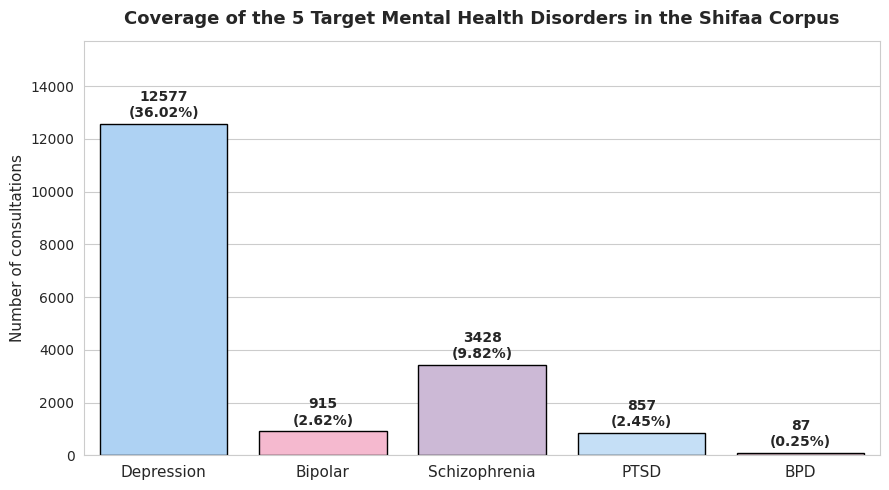

In [ ]:
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Montage Drive + chargement
drive.mount('/content/drive', force_remount=False)

BASE_DRIVE = '/content/drive/MyDrive/Master_Thesis_RAG_Indexes'
SHIFAA_DIR = f"{BASE_DRIVE}/Shifaa"
csv_path = f"{SHIFAA_DIR}/shifaa_prepared_rag.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ Fichier introuvable : {csv_path}")

df = pd.read_csv(csv_path)
print(f"✅ Corpus Shifaa chargé : {len(df):,} consultations\n")

# 2. Distribution des catégories mères (colonne 'disorder' ou 'Main_Category')
cat_col = 'disorder' if 'disorder' in df.columns else 'Main_Category' if 'Main_Category' in df.columns else None
if cat_col:
    print(f"📊 Distribution des catégories ({cat_col}) :")
    print(df[cat_col].value_counts(normalize=True).round(3) * 100)
    print()

# 3. Vocabulaire contrôlé : troubles cibles -> motifs arabes
DISORDER_PATTERNS = {
    "Depression":    ["اكتئاب", "الاكتئاب"],
    "Bipolar":       ["ثنائي القطب", "الثنائي القطب", "هوس الاكتئاب"],
    "Schizophrenia": ["فصام", "الفصام", "ذهان", "الذهان"],
    "PTSD":          ["صدمة", "الصدمة", "ما بعد الصدمة"],
    "BPD":           ["حدية", "الحدية", "الشخصية الحدية"],
}

rows = []
for disorder, patterns in DISORDER_PATTERNS.items():
    # Recherche dans toutes les colonnes textuelles (text, RAG_Document, etc.)
    text_cols = [c for c in df.columns if df[c].dtype == object]
    mask = pd.Series(False, index=df.index)
    for col in text_cols:
        mask |= df[col].fillna("").apply(lambda t: any(p in t for p in patterns))

    n = int(mask.sum())
    rows.append({
        "disorder": disorder,
        "arabic_patterns": " / ".join(patterns[:2]),
        "n_consultations": n,
        "pct_of_corpus": round(100 * n / len(df), 2),
    })

coverage = pd.DataFrame(rows)
print("=" * 70)
print("COUVERTURE DES 5 TROUBLES CIBLES DANS SHIFAA")
print("=" * 70)
print(coverage.to_string(index=False))
print(f"\nTotal couvert (chevauchements possibles) : {coverage['n_consultations'].sum():,}")



# 5. Figure pour le rapport
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['#a2d2ff', '#ffafcc', '#cdb4db', '#bde0fe', '#ffc8dd']
bars = sns.barplot(data=coverage, x="disorder", y="n_consultations",
                   palette=palette, edgecolor="black", ax=ax)
for i, r in coverage.iterrows():
    ax.text(i, r["n_consultations"] + coverage["n_consultations"].max() * 0.02,
            f"{r['n_consultations']}\n({r['pct_of_corpus']}%)",
            ha="center", fontsize=10, fontweight="bold")
ax.set_title("Coverage of the 5 Target Mental Health Disorders in the Shifaa Corpus",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of consultations", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, coverage["n_consultations"].max() * 1.25)
plt.xticks(fontsize=11)
plt.tight_layout()
fig_path = f"{SHIFAA_DIR}/fig_shifaa_coverage.png"
plt.savefig(fig_path, dpi=200)
print(f"✅ Figure sauvegardée : {fig_path}")
plt.show()